# Smart Food Image Generator - Assignment

[View on Google Colab](https://colab.research.google.com/drive/1Hwv2LPI8CGO7pNfTaA462e4Ywkht_NkC?usp=sharing)

Week 8: Multimodal AI for Food Delivery Business

OBJECTIVE: Build an AI system that can generate professional food images
and analyze them for safety using Stable Diffusion and BLIP models.

LEARNING GOALS:
- Use Stable Diffusion for text-to-image generation
- Use BLIP VQA for food analysis and safety detection
- Combine multiple AI models for practical food delivery applications
- Build a complete food generation and analysis pipeline

### Import the necessary libraries

In [1]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
from diffusers import StableDiffusionPipeline
from transformers import BlipProcessor, BlipForQuestionAnswering

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

In [2]:
def setup_device():
    """
    Setup device for optimal performance

    SOLUTION: Check for available hardware and return appropriate device and data type.
    """
    if torch.cuda.is_available():
        return "cuda", torch.float16
    elif torch.backends.mps.is_available():
        return "mps", torch.float32
    else:
        return "cpu", torch.float32

# TEST: Setup device
print("🔧 TESTING: Setting up device...")
device, dtype = setup_device()
print(f"Using device: {device}")
print()

🔧 TESTING: Setting up device...
Using device: cuda



---

### Load Models

In [3]:
def load_models(device, dtype):
    """
    Load all required models for food generation and analysis

    TODO: Load Stable Diffusion and BLIP models
    HINT: Use the model loading patterns from Week8 notebooks
    HINT: Use 'global' keyword to modify global variables

    MODELS TO LOAD:
    - Stable Diffusion: "runwayml/stable-diffusion-v1-5"
    - BLIP VQA: "Salesforce/blip-vqa-base"

    Args:
        device: Device to load models on
        dtype: Data type for models

    Returns:
        tuple: (text2img_pipeline, blip_model, blip_processor)
    """
    global text2img_pipe, blip_model, blip_processor

    stable_diffusion_model_name = "runwayml/stable-diffusion-v1-5"
    blip_vqa_model_name = "Salesforce/blip-vqa-base"

    print("📦 Loading models...")

    # TODO: Load Stable Diffusion pipeline
    # text2img_pipe = ?
    # text2img_pipe = text2img_pipe.to(device)

    print(f"Load Stable Diffusion pipeline for text-to-image generation.: {stable_diffusion_model_name}")
    text2img_pipe = StableDiffusionPipeline.from_pretrained(
        stable_diffusion_model_name,
        torch_dtype=dtype,
        safety_checker=None,
        requires_safety_checker=False
    )
    text2img_pipe = text2img_pipe.to(device)
    #if hasattr(text2img_pipe, 'enable_attention_slicing'):
    #    text2img_pipe.enable_attention_slicing()
    print("Stable Diffusion pipeline for text-to-image loaded successfully!")

    # TODO: Load BLIP VQA model and processor
    # blip_model = ?
    # blip_processor = ?
    # blip_model.eval()

    print(f"Loading BLIP VQA model: {blip_vqa_model_name}")
    blip_model = BlipForQuestionAnswering.from_pretrained(blip_vqa_model_name)
    blip_processor = BlipProcessor.from_pretrained(blip_vqa_model_name)
    blip_model.eval()
    print("VQA model loaded successfully!")
    #print(f"Model config: {blip_vqa_model.config}")


    # DUMMY IMPLEMENTATION (Remove this when implementing)
    #print("⚠️ DUMMY: Models not loaded yet - implement the TODO sections above")

    print("✅ All models loaded successfully!")
    return text2img_pipe, blip_model, blip_processor

# TEST: Load models
print("📦 TESTING: Loading models...")
text2img_pipe, blip_model, blip_processor = load_models(device, dtype)

📦 TESTING: Loading models...
📦 Loading models...
Load Stable Diffusion pipeline for text-to-image generation.: runwayml/stable-diffusion-v1-5


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

VQA model loaded successfully!
✅ All models loaded successfully!


---

### Generate Food Image

🍽️ TESTING: Generating food image...
🍽️ Generating: gnocchi al pesto


  0%|          | 0/20 [00:00<?, ?it/s]

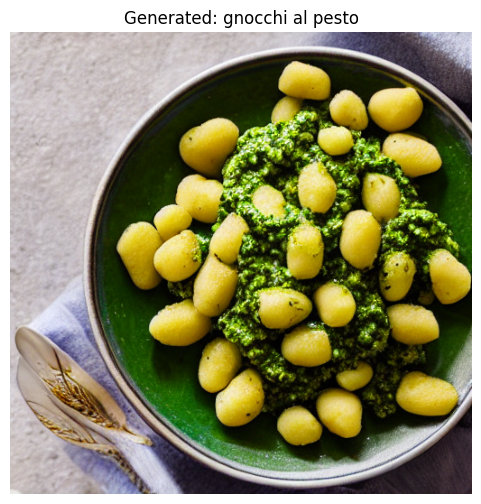

In [6]:
def generate_food_image(food_description, seed=42):
    """
    Generate professional food image from text description

    TODO: Implement food image generation using Stable Diffusion
    HINT: Enhance the prompt with food photography terms
    HINT: Use negative prompts to avoid unappetizing results
    HINT: Set seed for reproducible results

    Args:
        food_description (str): Description of food to generate
        seed (int): Random seed for reproducibility

    Returns:
        PIL.Image: Generated food image

    EXAMPLE INPUT: "butter chicken with rice and naan"
    EXAMPLE OUTPUT: PIL Image of appetizing butter chicken dish
    """
    print(f"🍽️ Generating: {food_description}")

    # TODO: Enhance prompt for better food photography
    #prompt = f"{food_description}, professional food photography, appetizing, restaurant style"

    # ✅ Enhanced positive prompt
    prompt = (
        f"{food_description}, on a plate, gourmet presentation, "
        "professional food photography, top down view, soft natural lighting, "
        "shallow depth of field, high detail, appetizing, colorful, vibrant, "
        "restaurant quality, styled by a food stylist, clean background"
    )

    # ❌ Negative prompt to avoid unwanted elements
    negative_prompt = (
        "blurry, overexposed, dark shadows, dirty plate, unappetizing, low quality, "
        "extra limbs, plastic food, poorly drawn, bad anatomy, logo, text"
    )

    # You'd pass both prompts to your image generation pipeline, e.g.:
    # result = stable_diffusion_pipeline(prompt=prompt, negative_prompt=negative_prompt, seed=seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    # TODO: Generate image using Stable Diffusion
    # with torch.no_grad():
    #     result = ?
    with torch.no_grad():
        result = text2img_pipe(
            prompt=prompt,
            #negative_prompt="blurry, low quality",
            negative_prompt=negative_prompt,
            #num_images_per_prompt=1,
            num_inference_steps=20,
            guidance_scale=7.5
        )
    # TODO: Return the generated image
    return result.images[0]

    # DUMMY IMPLEMENTATION (Remove this when implementing)
    #print("⚠️ DUMMY: Would generate food image here")
    # Create a dummy image for testing
    dummy_image = Image.new('RGB', (512, 512), color='lightblue')
    return dummy_image

# TEST: Generate food image
print("🍽️ TESTING: Generating food image...")
test_food = "gnocchi al pesto"
food_image = generate_food_image(test_food)

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(food_image)
plt.title(f"Generated: {test_food}")
plt.axis('off')
plt.show()
print()

---

### Question Answering about Food

In [9]:
def ask_about_food(image, question):
    """
    Ask questions about food using BLIP VQA

    TODO: Implement visual question answering using BLIP
    HINT: Process image and question, then generate answer
    HINT: Use the global blip_model and blip_processor

    Args:
        image (PIL.Image): Food image to analyze
        question (str): Question to ask about the food

    Returns:
        str: Answer to the question

    EXAMPLE INPUT:
        image = <PIL Image of curry>
        question = "Does this contain dairy?"

    EXAMPLE OUTPUT: "yes"
    """

    # TODO: Process image and question using BLIP
    # inputs = ?
    inputs =  blip_processor(image, question, return_tensors="pt")

    # TODO: Generate answer
    # with torch.no_grad():
    #     out = ?
    with torch.no_grad():
        out = blip_model.generate(
            **inputs,
            max_length=20,
            num_beams=5,
            early_stopping=True
        )
    # TODO: Decode and return answer
    # answer = ?
    # return answer.strip()
    answer = blip_processor.decode(out[0], skip_special_tokens=True)
    print(f"Q: '{question}'")
    print(f"A: '{answer.strip()}'")

    # DUMMY IMPLEMENTATION (Remove this when implementing)
    #print(f"⚠️ DUMMY: Would answer '{question}' about the food")
    #return "unknown"
    return answer.strip()

# TEST: Ask questions about food
print("❓ TESTING: Asking questions about food...")
questions = [
    "What type of food is this?",
    "Does this contain dairy?",
    "Is this food spicy?"
]

for question in questions:
    answer = ask_about_food(food_image, question)
    print(f"Q: {question}")
    print(f"A: {answer}")
    print()


❓ TESTING: Asking questions about food...
Q: 'What type of food is this?'
A: 'broccoli'
Q: What type of food is this?
A: broccoli

Q: 'Does this contain dairy?'
A: 'no'
Q: Does this contain dairy?
A: no

Q: 'Is this food spicy?'
A: 'no'
Q: Is this food spicy?
A: no



---

### Analyze Food Safety

In [11]:
def analyze_food_safety(food_image):
    """
    Analyze food for ingredients and allergens

    TODO: Implement comprehensive food safety analysis
    HINT: Ask specific questions about allergens and dietary info
    HINT: Check for common allergens: dairy, nuts, eggs, gluten

    Args:
        food_image (PIL.Image): Food image to analyze

    Returns:
        dict: Analysis results with description, allergens, and dietary info

    EXAMPLE OUTPUT: {
        "description": "butter chicken with rice",
        "allergens": ["dairy", "gluten"],
        "vegetarian": "no",
        "spicy": "yes"
    }
    """
    print("🔬 Analyzing food safety...")

    # Get basic info
    description = ask_about_food(food_image, "What type of food is this?")

    # Check for common allergens
    allergen_questions = [
        "Does this contain dairy or milk?",
        "Does this contain nuts?",
    ]
    allergens = []
    for question in allergen_questions:
        answer = ask_about_food(food_image, question)
        if "yes" in answer.lower():
            allergen = question.split("contain ")[-1].split("?")[0]
            allergens.append(allergen)

    # TODO: Get dietary information
    # vegetarian = ask_about_food(food_image, ?)
    # Check for vegetarian
    vegetarian_questions = [
        "Is this dish vegetarian?",
        "Does this dish contain any meat, fish, or eggs?",
        "Is there any visible meat or animal product in this food?",
        "Would this be suitable for a vegetarian diet?"
    ]

    vegetarians = []
    for question in vegetarian_questions:
        answer = ask_about_food(food_image, question)
        if "yes" in answer.lower():
            vegetarian = question.split("contain ")[-1].split("?")[0]
            vegetarians.append(vegetarian)

    # TODO: Get dietary information
    # spicy = ask_about_food(food_image, ?)
    # Check for spicy
    spicy_questions = [
        "Is this dish spicy?",
        "Does this food contain chili or hot spices?",
        "Would this be considered a hot or spicy dish?",
        "Are there visible red chili flakes or peppers?"
    ]

    spicys = []
    for question in spicy_questions:
        answer = ask_about_food(food_image, question)
        if "yes" in answer.lower():
            spicy = question.split("contain ")[-1].split("?")[0]
            spicys.append(spicy)


    #TODO: Compile analysis results
    analysis = {
        "description": description,
        "allergens": allergens,
        "vegetarian": vegetarians,
        "spicy": spicys
    }

    # DUMMY IMPLEMENTATION (Remove this when implementing)
    # analysis = {
    #     "description": "unknown food",
    #     "allergens": [],
    #     "vegetarian": "unknown",
    #     "spicy": "unknown"
    # }
    # print("⚠️ DUMMY: Returning fake analysis results")

    print("✅ Food analysis complete!")
    return analysis

# TEST: Analyze food safety
print("🔬 TESTING: Food safety analysis...")
analysis = analyze_food_safety(food_image)

print("Analysis Results:")
print(f"Description: {analysis['description']}")
print(f"Allergens: {', '.join(analysis['allergens']) if analysis['allergens'] else 'None detected'}")
print(f"Vegetarian: {analysis['vegetarian']}")
print(f"Spicy: {analysis['spicy']}")

🔬 TESTING: Food safety analysis...
🔬 Analyzing food safety...
Q: 'What type of food is this?'
A: 'broccoli'
Q: 'Does this contain dairy or milk?'
A: 'yes'
Q: 'Does this contain nuts?'
A: 'no'
Q: 'Is this dish vegetarian?'
A: 'yes'
Q: 'Does this dish contain any meat, fish, or eggs?'
A: 'no'
Q: 'Is there any visible meat or animal product in this food?'
A: 'no'
Q: 'Would this be suitable for a vegetarian diet?'
A: 'yes'
Q: 'Is this dish spicy?'
A: 'no'
Q: 'Does this food contain chili or hot spices?'
A: 'no'
Q: 'Would this be considered a hot or spicy dish?'
A: 'hot'
Q: 'Are there visible red chili flakes or peppers?'
A: 'no'
✅ Food analysis complete!
Analysis Results:
Description: broccoli
Allergens: dairy or milk
Vegetarian: ['Is this dish vegetarian', 'Would this be suitable for a vegetarian diet']
Spicy: []


---

### Generate and Analyze Food

🚀 TESTING: Complete pipeline...

--- Testing: chocolate chip cookies ---
🚀 Complete pipeline for: chocolate chip cookies
🍽️ Generating: spaghetti al sugo


  0%|          | 0/20 [00:00<?, ?it/s]

🔬 Analyzing food safety...
Q: 'What type of food is this?'
A: 'spaghetti'
Q: 'Does this contain dairy or milk?'
A: 'no'
Q: 'Does this contain nuts?'
A: 'yes'
Q: 'Is this dish vegetarian?'
A: 'yes'
Q: 'Does this dish contain any meat, fish, or eggs?'
A: 'no'
Q: 'Is there any visible meat or animal product in this food?'
A: 'no'
Q: 'Would this be suitable for a vegetarian diet?'
A: 'yes'
Q: 'Is this dish spicy?'
A: 'yes'
Q: 'Does this food contain chili or hot spices?'
A: 'chili'
Q: 'Would this be considered a hot or spicy dish?'
A: 'hot'
Q: 'Are there visible red chili flakes or peppers?'
A: 'no'
✅ Food analysis complete!


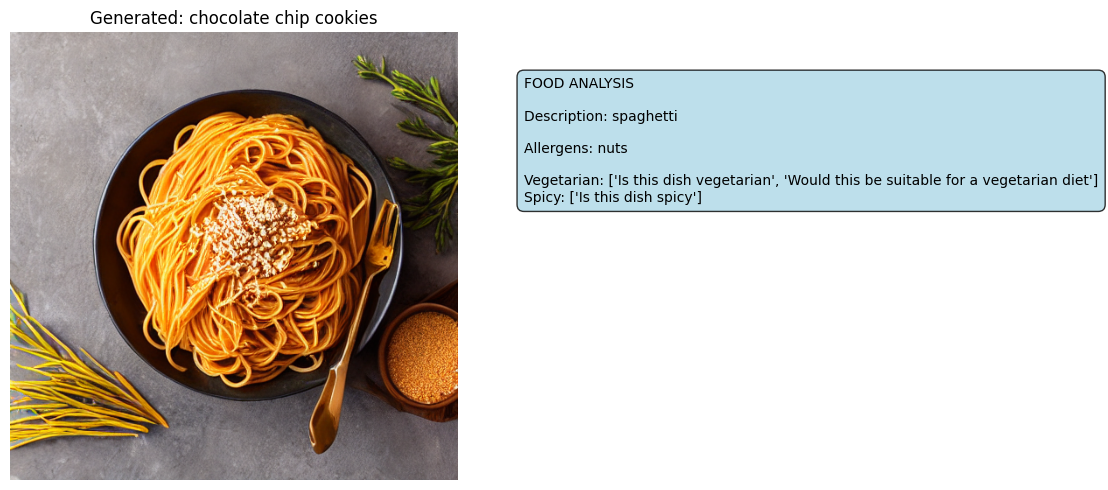



--- Testing: grilled salmon with vegetables ---
🚀 Complete pipeline for: grilled salmon with vegetables
🍽️ Generating: spaghetti al sugo


  0%|          | 0/20 [00:00<?, ?it/s]

🔬 Analyzing food safety...
Q: 'What type of food is this?'
A: 'spaghetti'
Q: 'Does this contain dairy or milk?'
A: 'no'
Q: 'Does this contain nuts?'
A: 'yes'
Q: 'Is this dish vegetarian?'
A: 'yes'
Q: 'Does this dish contain any meat, fish, or eggs?'
A: 'no'
Q: 'Is there any visible meat or animal product in this food?'
A: 'no'
Q: 'Would this be suitable for a vegetarian diet?'
A: 'yes'
Q: 'Is this dish spicy?'
A: 'yes'
Q: 'Does this food contain chili or hot spices?'
A: 'chili'
Q: 'Would this be considered a hot or spicy dish?'
A: 'hot'
Q: 'Are there visible red chili flakes or peppers?'
A: 'no'
✅ Food analysis complete!


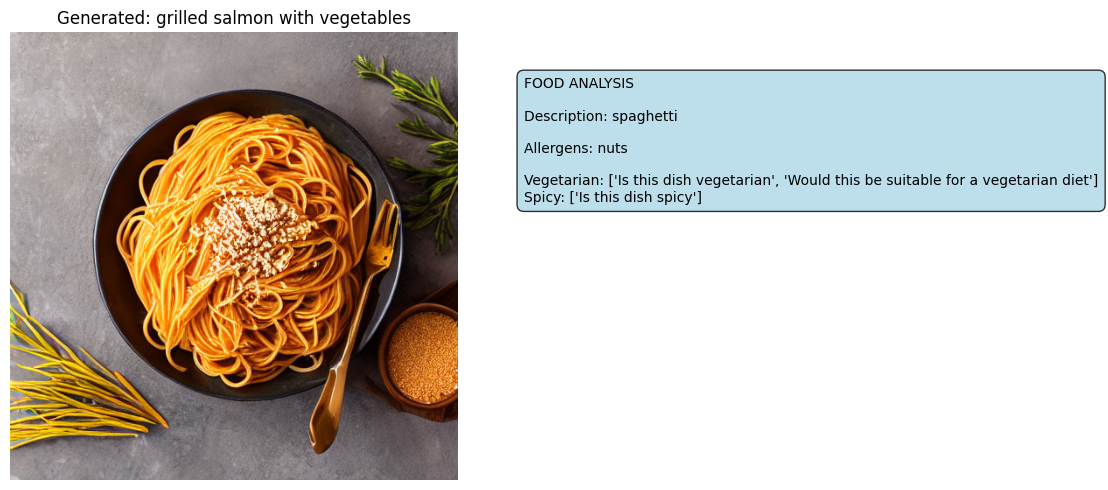

In [13]:
def generate_and_analyze_food(food_description):
    """
    Complete pipeline: generate food image and analyze it

    TODO: Implement the complete food generation and analysis pipeline
    HINT: Combine image generation with safety analysis
    HINT: Display results in a side-by-side format

    Args:
        food_description (str): Description of food to generate and analyze

    Returns:
        tuple: (generated_image, analysis_results)

    PIPELINE STEPS:
    1. Generate food image using generate_food_image()
    2. Analyze the food using analyze_food_safety()
    3. Display results with image and analysis side-by-side
    4. Return both image and analysis
    """
    print(f"🚀 Complete pipeline for: {food_description}")

    # TODO: Step 1 - Generate food image
    # food_image = generate_food_image(?)
    food_image = generate_food_image(food_description)

    # TODO: Step 2 - Analyze the food
    # analysis = analyze_food_safety(?)
    analysis = analyze_food_safety(food_image)

    # TODO: Step 3 - Display results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # # Show image
    ax1.imshow(food_image)
    ax1.set_title(f"Generated: {food_description}")
    ax1.axis('off')

    # # Show analysis
    ax2.axis('off')
    analysis_text = f"FOOD ANALYSIS\n\n"
    analysis_text += f"Description: {analysis['description']}\n\n"
    analysis_text += f"Allergens: {', '.join(analysis['allergens']) if analysis['allergens'] else 'None detected'}\n\n"
    analysis_text += f"Vegetarian: {analysis['vegetarian']}\n"
    analysis_text += f"Spicy: {analysis['spicy']}"

    ax2.text(0.1, 0.9, analysis_text, transform=ax2.transAxes,
              fontsize=10, verticalalignment='top',
              bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8))

    plt.tight_layout()
    plt.show()

    # TODO: Step 4 - Return results
    return food_image, analysis

    # DUMMY IMPLEMENTATION (Remove this when implementing)
    # print("⚠️ DUMMY: Would run complete pipeline here")
    # dummy_image = Image.new('RGB', (512, 512), color='lightgreen')
    # dummy_analysis = {"description": "test food", "allergens": [], "vegetarian": "unknown", "spicy": "unknown"}

    # # Simple display for dummy
    # plt.figure(figsize=(6, 4))
    # plt.imshow(dummy_image)
    # plt.title(f"DUMMY: {food_description}")
    # plt.axis('off')
    # plt.show()

    # return dummy_image, dummy_analysis

# TEST: Complete pipeline
print("🚀 TESTING: Complete pipeline...")
test_foods = [
    "spaghetti carbonara",
    "chocolate chip cookies",
    "grilled salmon with vegetables"
]

for food in test_foods:
    print(f"\n--- Testing: {food} ---")
    img, result = generate_and_analyze_food(food)
    print()

---